Data can be downloaded from https://drive.google.com/drive/folders/1NkwomrirVVgRe2OLMzvg6Qhq4-zcOHfD?usp=sharing 

Place downloaded data folder SCC under ./tutorial/

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

In [4]:
from pyStrint import plotting as pl
from pyStrint import preprocess as pp
from pyStrint import evaluation as eva
# import sys
# sys.path.insert(0, '/data6/5.Simpute/StrInt-main/')
# from Strint import plotting as pl
# from Strint import preprocess as pp
# from Strint import evaluation as eva

# 0. Load data

In [35]:
spex_inputDir = './tutorial/SCC'
Raw_inputDir = './tutorial/SCC/inputs'
outDir = './tutorial/SCC'

In [6]:
palette_dict = {'Original':'#ef8a62','Refined':'#67a9cf','ST':"#C798EE"}

major_color_map = {'Myeloid':'#EC7063',
 'Endo':'#22a8a1',
 'KC':'#28B463',
 'KC (Cyc)':'#63C1A3',
 'KC (Diff)':'#59BE86',
 'KC (Basal)':'#76D7C4',
 'FB':"#3A84E6",
 'LC':'#3498DB',
 'T cell':'#E88AC2',
 'Epithelial':'#9DB0D4',
 'TSK':'#E74C3C',
 'B cell':'#ffb200',
 'Melanocyte':'#85C1E9',
 'NK':'#C798EE'}

color_map = {'ASDC': '#E74C3C',
 'MDSC':'#F56867',
 'B_Cell': '#D35400',
'B Cell': '#D35400',
 'CD1C': '#EC7063',
 'CD4_Naive': '#DC7633',
 'CD4_Pre_Exh': '#D95F02',
 'CD8_EM': '#ffb200',
 'CD8_Exh': '#ed5eb3',
 'CLEC9A': '#F5B7B1',
 'Eccrine': '#1B9E77',
 'Endothelial_Cell': '#28B463',
  'Endothelial Cell': '#28B463',
 'Fibroblast': '#85C1E9',
 'Keratinocyte': '#58D68D',
 'LC': '#22a8a1',
 'Mac': '#EC7063',
 'Melanocyte': '#2B83BA',
 'Mig_CD1C': '#007FFF',
 'Mig_CLEC9A': '#3498DB',
 'Mig_LC': '#00c9ff',
 'NK': '#8cc63f',
 'PDC': '#9DB0D4',
 'Pilosebaceous': '#5E3C99',
 'TSK': '#EC7063',
 'Treg': '#22a8a1',
 'Tumor_KC_Basal': '#AF7AC5',
 'Tumor_KC_Cyc': '#D2B4DE',
 'Tumor_KC_Diff': '#E88AC2'}

minor_map = {'CLEC9A': 'Myeloid',
 'Endothelial_Cell': 'Endo',
 'Endothelial Cell': 'Endo',
 'CD1C': 'Myeloid',
 'Keratinocyte': 'KC',
 'Tumor_KC_Cyc': 'KC (Cyc)',
 'Fibroblast': 'FB',
 'LC': 'LC',
 'Mig_CD1C': 'Myeloid',
 'Mac': 'Myeloid',
 'Tumor_KC_Basal': 'KC (Basal)',
 'ASDC': 'Myeloid',
 'CD8_Exh': 'T cell',
 'Pilosebaceous': 'Epithelial',
 'Tumor_KC_Diff': 'KC (Diff)',
 'PDC': 'Myeloid',
 'Mig_LC': 'LC',
 'Treg': 'T cell',
 'TSK': 'TSK',
 'MDSC': 'Myeloid',
 'Eccrine': 'Epithelial',
 'B_Cell': 'B cell',
  'B Cell': 'B cell',
 'Melanocyte': 'Melanocyte',
 'CD8_EM': 'T cell',
 'CD4_Naive': 'T cell',
 'CD4_Pre_Exh': 'T cell',
 'Mig_CLEC9A': 'Myeloid',
 'NK': 'NK'}

In [14]:
species = 'Human'
new_exp_fn = f'{spex_inputDir}/alter_sc_exp.tsv'
new_meta_fn = f'{spex_inputDir}/spexmod_sc_meta.tsv'

alter_exp = pd.read_csv(new_exp_fn,sep='\t',index_col=0,header=0)
sc_agg_meta = pd.read_csv(new_meta_fn,sep='\t',index_col=0,header=0)
sc_agg_meta['adj_spex_UMAP2'] = sc_agg_meta['adj_spex_UMAP2']*-1
sc_agg_meta['st_y'] = sc_agg_meta['st_y']*-1
refine_adata = pp.make_adata(alter_exp,sc_agg_meta,species,save_path = outDir, save_adata = False)
refine_adata.obs['celltype_major'] = refine_adata.obs['celltype'].map(minor_map)
refine_adata.uns['tp_key'] = 'celltype_major'
refine_adata.uns['major_color_map'] = major_color_map
refine_adata.uns['rscript_path'] = '/apps/software/R/4.2.0-foss-2021b/bin/Rscript'
refine_adata.uns['python_path'] = '/apps/software/Anaconda3/2022.05/bin/python'
# del alter_exp

/home/wangjingwan/.local/lib/python3.8/site-packages/anndata/compat/_overloaded_dict.py:106: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  self.data[key] = value


# 1. Overview

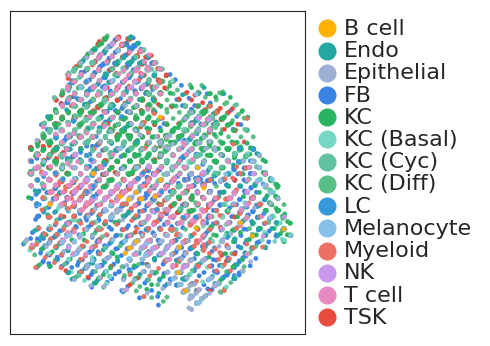

<Figure size 640x480 with 0 Axes>

In [14]:
pl.sc_celltype(refine_adata, color_map = major_color_map,tp_key = 'celltype_major', figsize= (3.8,4.2),
        legend = True, size = 10, alpha = 1, savefig = True)

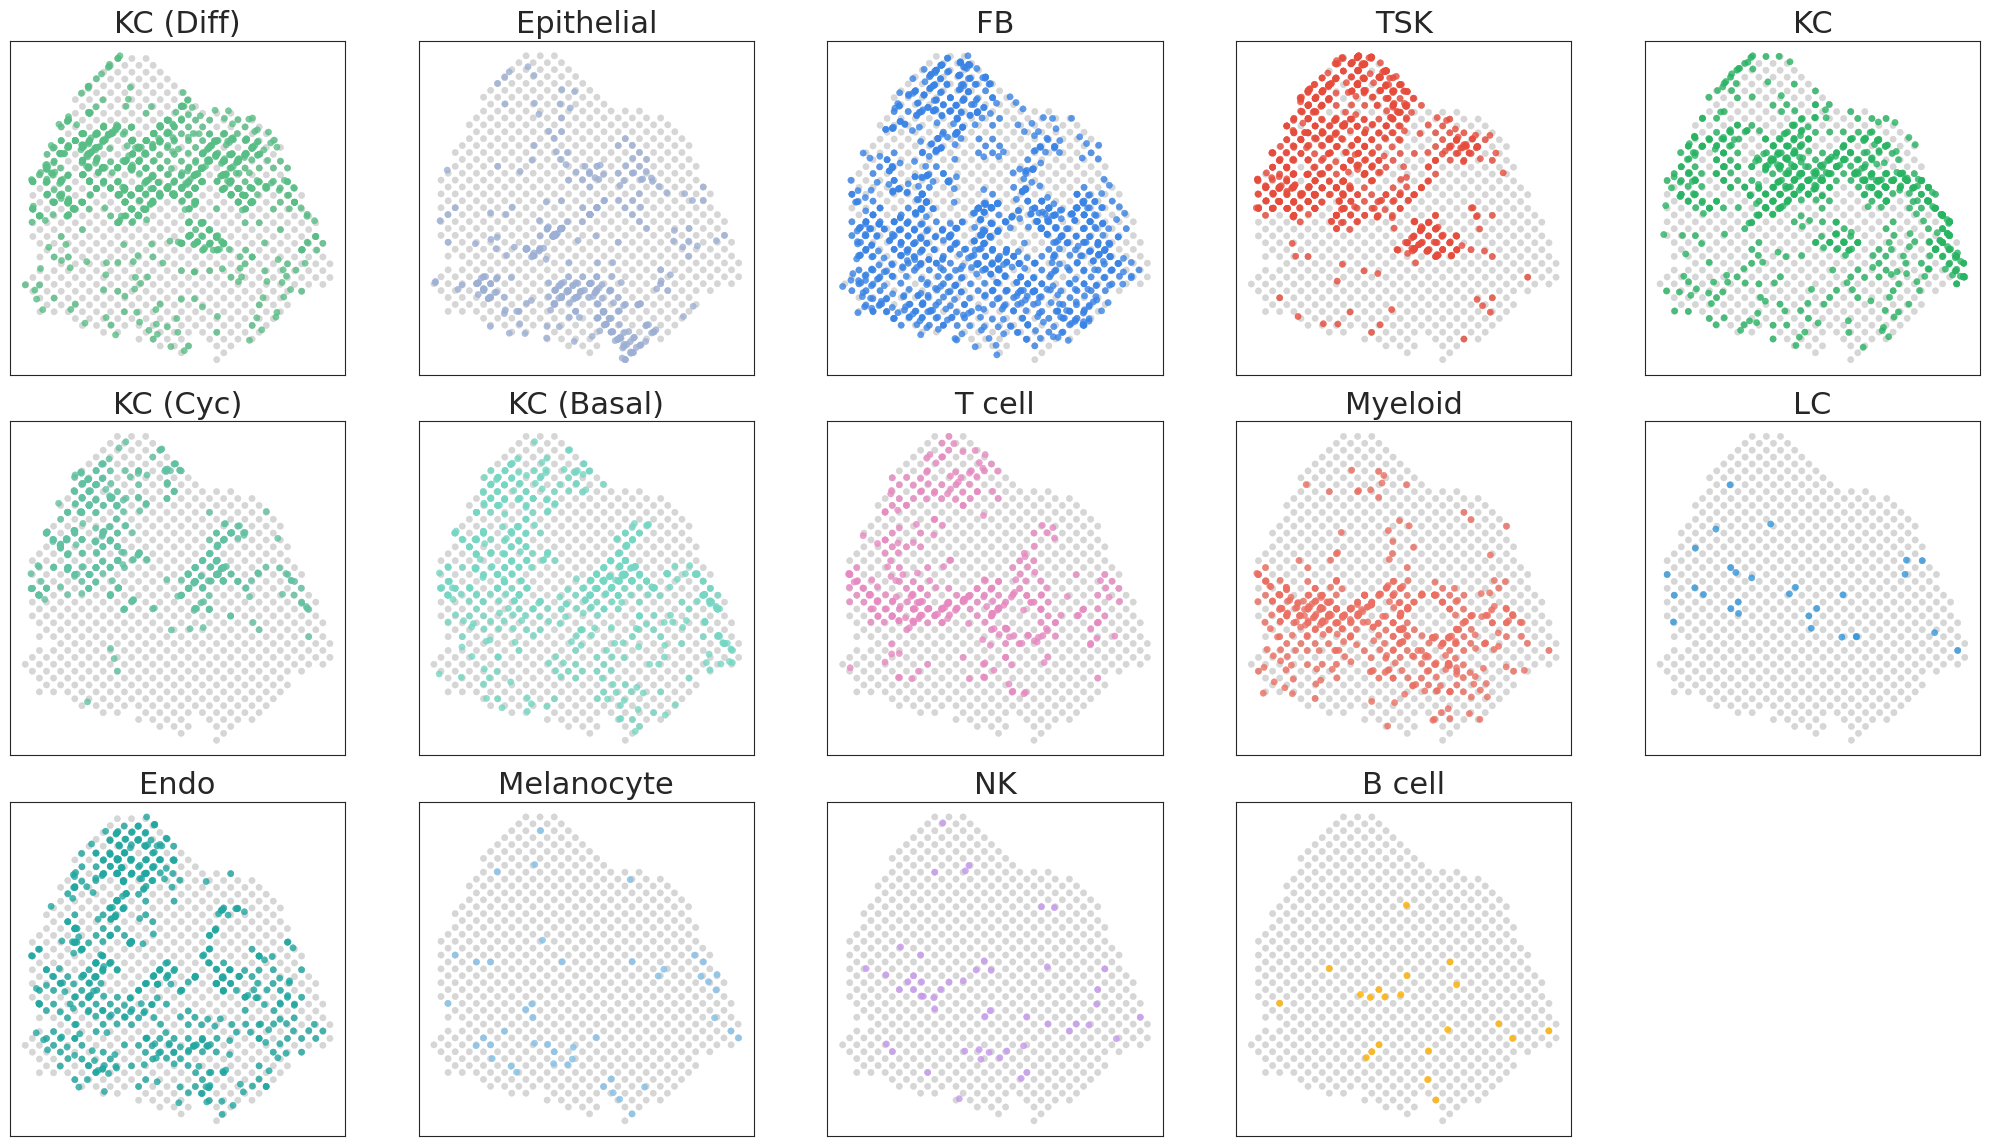

<Figure size 640x480 with 0 Axes>

In [15]:
pl.sc_subtype(refine_adata,color_map = major_color_map,tp_key = 'celltype_major', savefig = True)

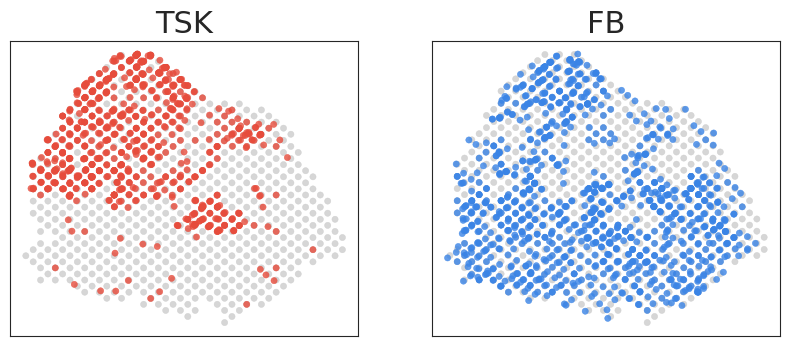

<Figure size 640x480 with 0 Axes>

In [16]:
pl.sc_subtype(refine_adata,color_map = major_color_map,tp_key = 'celltype_major',target_tp = ['TSK','FB'], savefig = True)

# 2. Spot Correlation

In [17]:
refine_spot_cor = eva.runSpotCor(refine_adata, recon_exp_file = new_exp_fn,
                                 recon_meta_file = new_meta_fn,
               orig_sc_file = f'{Raw_inputDir}/SC_exp.tsv', orig_st_file = f'{Raw_inputDir}/ST_exp.tsv')

In [18]:
before_spot_cor = eva.runSpotCor(refine_adata, recon_exp_file = '',
                                 recon_meta_file = new_meta_fn,
               orig_sc_file = f'{Raw_inputDir}/SC_exp.tsv', orig_st_file = f'{Raw_inputDir}/ST_exp.tsv')

No exp file, Pull cells from original sc_exp


In [19]:
refine_spot_cor.mean()

cor    0.678946
dtype: float64

In [20]:
before_spot_cor.mean()

cor    0.664092
dtype: float64

In [21]:
before_spot_cor['Method'] = 'Original'
refine_spot_cor['Method'] = 'Refined'
spot_cor = pd.concat([before_spot_cor,refine_spot_cor])

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Original vs. Refined: t-test independent samples with Benjamini-Hochberg correction, P_val:2.974e-03 t=-2.976e+00


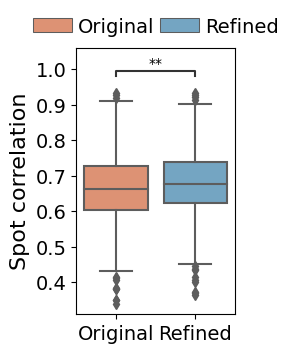

In [39]:
pl.boxplot(spot_cor,palette_dict = palette_dict,
                x='Method', y='cor', hue='Method', ylabel='Spot correlation', legend = True,
                test = 't-test_ind',figsize=(2.4,3.4),savefig =refine_adata.uns['figpath'] + 'spot_cor.pdf')

# 3. SpaTalk

Before executing the code below, ensure that the SpaTalk R library is installed.  
You can find the installation instructions at [https://github.com/ZJUFanLab/SpaTalk](https://github.com/ZJUFanLab/SpaTalk).

In [15]:
refine_adata

AnnData object with n_obs × n_vars = 6696 × 15386
    obs: 'sc_id', 'spot', 'exp_cor_before', 'interface_cor_before', 'mix_cor_before', 'exp_cor_after', 'interface_cor_after', 'mix_cor_after', 'celltype', 'UMAP1', 'UMAP2', 'st_x', 'st_y', 'spex_UMAP1', 'spex_UMAP2', 'indice', 'core1', 'core2', 'centering_scale_factor', 'adj_spex_UMAP1', 'adj_spex_UMAP2', 'celltype_major'
    var: 'symbol', 'MT_gene'
    uns: 'figpath', 'save_path', 'species', 'tp_key', 'major_color_map', 'rscript_path', 'python_path'
    obsm: 'MT'

In [16]:
# SpaTalk is time cosuming, so we normally run with, using the output at ./SCC/spatalk to proceed

# meta_key is the column that used for spaTalk. 
# Here I want the spatalk result to be more detailed, so I use 'celltype' as meta_key.
# The spatalk result will then be combined with the tp_key.
eva.runSpaTalk(refine_adata, rscript_executable = '/apps/software/R/4.2.0-foss-2021b/bin/Rscript',
               tp_key = 'celltype_major', meta_key = 'celltype', st_dir= new_exp_fn, st_meta_dir= new_meta_fn)

In [17]:
draw_rec,draw_send = eva.generate_cci(refine_adata, return_df = True)

In [18]:
sender_order = ['B cell','T cell','Myeloid','Melanocyte','NK',
                'TSK', 'KC', 'KC (Basal)', 'KC (Cyc)', 'KC (Diff)',
                'FB', 'Endo', 'Epithelial','LC']

4 6


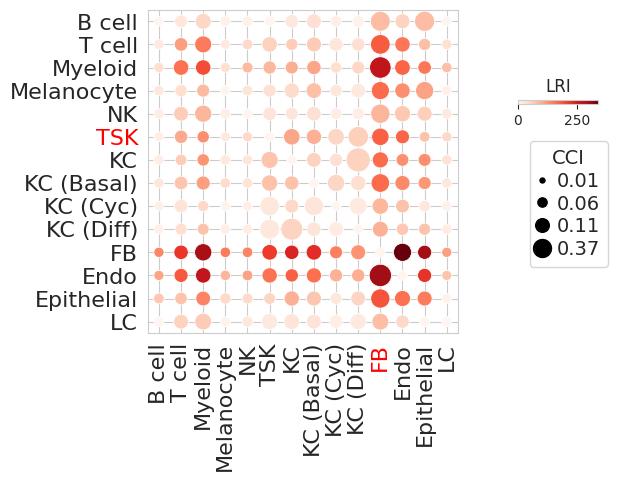

<Figure size 640x480 with 0 Axes>

In [19]:
pl.celltype_cci(refine_adata, is_sender_per = True, figsize = (4,6), 
            target_sender = sender_order, target_receiver = sender_order,
             y_highlight=['TSK'], x_highlight=['FB'],
                cmap = 'Reds', size = 'CCI',hue = 'LRI',
                savefig = True,color_bar_pos = [1.05, 0.38, 0.2, 0.35])

# 4. CCI

## 4.1 LRI overview of target cell types

In [20]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
colors = {'red': '#9DC5D8', 'white': '#F5DAC9', 'blue': '#DF7D97'}
# Create a list of tuples specifying the color map
colors_map = [(0.0, colors['red']), (0.5, colors['white']), (1.0, colors['blue'])]
# Create the colormap using LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list('my_colormap', colors_map)

In [21]:
spa_res = refine_adata.uns['spatalk']
tsk_fb_spa = spa_res[(spa_res['celltype_sender'] == 'FB') & (spa_res['celltype_receiver'] == 'TSK')]
tsk_fb_spa

,ligand,receptor,celltype_sender,celltype_receiver,name,lr_co_exp_num,lr_co_ratio,lr_co_ratio_pvalue,score,CCI,LRI
10,ACTR2,ADRB2,FB,TSK,ACTR2-ADRB2-FB-TSK,140.0,0.076253,0.0,0.950924,FB-TSK,ACTR2-ADRB2
176,ADAM10,MET,FB,TSK,ADAM10-MET-FB-TSK,25.0,0.013617,0.0,0.895161,FB-TSK,ADAM10-MET
319,ADAM12,ITGB1,FB,TSK,ADAM12-ITGB1-FB-TSK,810.0,0.441176,0.0,0.758866,FB-TSK,ADAM12-ITGB1
348,ADAM12,SDC4,FB,TSK,ADAM12-SDC4-FB-TSK,295.0,0.160675,0.0,0.879877,FB-TSK,ADAM12-SDC4
519,ADAM17,ITGB1,FB,TSK,ADAM17-ITGB1-FB-TSK,191.0,0.104031,0.0,0.758866,FB-TSK,ADAM17-ITGB1
...,...,...,...,...,...,...,...,...,...,...,...
14461,VEGFA,GPC1,FB,TSK,VEGFA-GPC1-FB-TSK,132.0,0.071895,0.0,0.884460,FB-TSK,VEGFA-GPC1
14490,VEGFA,ITGAV,FB,TSK,VEGFA-ITGAV-FB-TSK,116.0,0.063181,0.0,0.892434,FB-TSK,VEGFA-ITGAV
14519,VEGFA,ITGB1,FB,TSK,VEGFA-ITGB1-FB-TSK,706.0,0.384532,0.0,0.758866,FB-TSK,VEGFA-ITGB1
14641,VIM,CD44,FB,TSK,VIM-CD44-FB-TSK,1826.0,0.994553,0.0,0.815521,FB-TSK,VIM-CD44


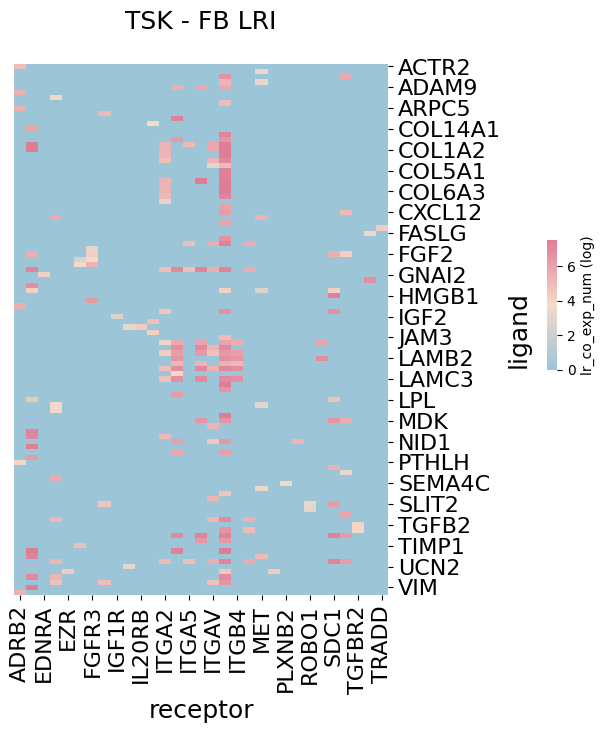

In [22]:
pl.clustermap(tsk_fb_spa, index = 'ligand', col = 'receptor', value = 'lr_co_exp_num',
                 aggfunc = 'sum', log = True, scale = False, row_cluster = False, col_cluster = False,
                 cmap = cmap, title = 'TSK - FB LRI', rotate_x = True,
                 xticks = True, yticks = True, xlabel = True, ylabel = True, cbar_x = 1.1,
                 figsize = (5,6.5),col_colors = None, row_colors = None,
                 savefig = refine_adata.uns['figpath'] + f'tsk_fb_spa_heatmap.pdf')

## 4.2 KEGG

In [23]:
kegg_enrich = eva.runKEGG(refine_adata, rscript_executable = '/apps/software/R/4.2.0-foss-2021b/bin/Rscript', 
            input_df = tsk_fb_spa, df_name = 'TSK_FB')

flexiblas Failed to load /apps/software/FlexiBLAS/3.0.4-GCC-11.2.0/lib/flexiblas//libflexiblas_openblas.so - error: libopenblas.so.0: cannot open shared object file: No such file or directory 
<flexiblas> No suitable BLAS backend could be loaded. Trying Fallback instead.


[1] "/data6/wangjingwan/5.Simpute/StrInt-main/tutorial/SCC/kegg"
[1] "TSK_FB_kegg.tsv"


'select()' returned 1:1 mapping between keys and columns
Reading KEGG annotation online: "https://rest.kegg.jp/link/hsa/pathway"...
Reading KEGG annotation online: "https://rest.kegg.jp/list/pathway/hsa"...


TSK_FB


In [24]:
pathway_dict = {}
for idx, row in kegg_enrich.head(5).iterrows():
    path = row['Description']
    genes = row['geneSymbol'].split('/')
    # print(genes)
    for gene in genes:
        if gene in pathway_dict:
            pathway_dict[gene].append(path)
        else:
            pathway_dict[gene] = [path]

In [25]:
lr_path_df = pd.DataFrame()
for idx, row in tsk_fb_spa.iterrows():
    lig = row['ligand']
    rec = row['receptor']
    if lig in pathway_dict and rec in pathway_dict:
        shared_pathway = set(pathway_dict[lig]).intersection(set(pathway_dict[rec]))
        # print(lig, rec,shared_pathway)
        for path in shared_pathway:
            # print(path)
            lr_path_df = pd.concat([lr_path_df, pd.DataFrame({'ligand':[lig], 'receptor':[rec], 'pathway':[path]})], ignore_index=True)

In [32]:
import importlib
importlib.reload(pl)

<module 'Strint.plotting' from '/data6/wangjingwan/5.Simpute/StrInt-main/Strint/plotting.py'>

In [33]:
pl.draw_lr_flow3(lr_path_df, left_panel = 'ligand', mid_panel = 'receptor', right_panel = 'pathway',
                 figsize = (10,26), outDir= refine_adata.uns['figpath'] + 'tsk_fb_flow.pdf')

# 5. Selected LRI

In [34]:
sender = 'TSK'
receiver = 'FB'
ligand = 'GRN'
receptor = 'TNFRSF1A'
print(f'{sender} to {receiver} {ligand} to {receptor}')

TSK to FB GRN to TNFRSF1A


Figure saved /data6/wangjingwan/5.Simpute/StrInt-main/tutorial/SCC/figures//TSK_FB_GRN_FB_arrow.pdf


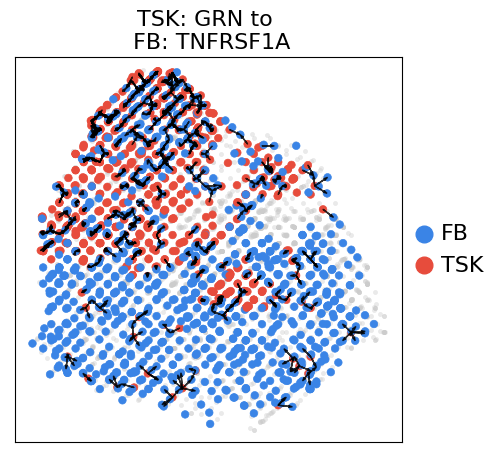

In [35]:
pl.LRI_of_CCI(refine_adata, sender = sender, receiver = receiver, ligand = ligand, receptor = receptor, subset = False, show_pair=False,
                hue = refine_adata.uns['tp_key'],color_map = major_color_map,figsize = (5,5),arrow_length = 0.5, size = 30,
                savefig=True)

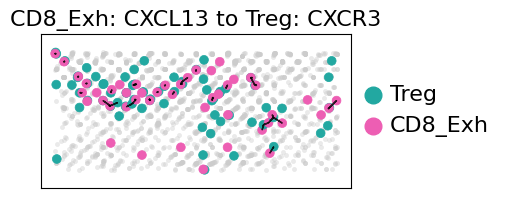

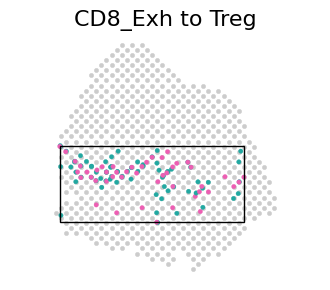

In [36]:
# if you want to use the detailed celltype, change the sender_tp and receiver_tp to the detailed celltype
# you can change back to the major celltype by reloading draw_rec,draw_send = eva.generate_cci(refine_adata, return_df = True)
refine_adata.uns['cellpair'][['sender_tp', 'receiver_tp']] = refine_adata.uns['cellpair']['Name'].str.split(' -- ',expand = True)

sender = 'CD8_Exh'
receiver = 'Treg'
ligand = 'CXCL13'
receptor = 'CXCR3'
target_cellpair1 = pl.LRI_of_CCI(refine_adata,sender = sender,receiver = receiver,ligand = ligand,receptor = receptor,hue = 'celltype',
                                color_map = color_map,figsize=(4,2),arrow_length = 0.2, size = 40)
draw_rec,draw_send = eva.generate_cci(refine_adata, return_df = True)

# 6. spatialDM

In [38]:
dm_dir = './tutorial/SCC/spatialDM/'

dm_res = pd.DataFrame()
for subdir in next(os.walk(dm_dir))[1]:
    path = f'{dm_dir}/{subdir}'
    if os.path.exists(f'{path}/spatialdm.csv'):
        print(subdir)
        spatialdm = pp.read_csv_tsv(f'{path}/spatialdm.csv')
        spatialdm['map'] = subdir
        spatialdm['decon'] = 'Cell2location'
        dm_res = pd.concat((dm_res,spatialdm),axis = 0)

dm_res = dm_res[dm_res['selected'] == True]
dm_res

ST
sprout
refined
original


,Ligand0,Ligand1,Ligand2,Receptor0,Receptor1,Receptor2,perm_pval,fdr,selected,map,decon,Receptor3,z_pval,z
EFNB1_EPHA4,EFNB1,NaN,NaN,EPHA4,NaN,NaN,0.0,0.000000e+00,True,ST,Cell2location,NaN,NaN,NaN
EFNB1_EPHB3,EFNB1,NaN,NaN,EPHB3,NaN,NaN,0.0,0.000000e+00,True,ST,Cell2location,NaN,NaN,NaN
EFNB1_EPHB4,EFNB1,NaN,NaN,EPHB4,NaN,NaN,0.0,0.000000e+00,True,ST,Cell2location,NaN,NaN,NaN
EFNB2_EPHB3,EFNB2,NaN,NaN,EPHB3,NaN,NaN,0.0,0.000000e+00,True,ST,Cell2location,NaN,NaN,NaN
EFNB2_EPHB4,EFNB2,NaN,NaN,EPHB4,NaN,NaN,0.0,0.000000e+00,True,ST,Cell2location,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
APLN_APLNR,APLN,NaN,NaN,APLNR,NaN,NaN,NaN,8.919231e-03,True,original,Cell2location,NaN,3.966574e-03,2.654902
CCL20_CCR6,CCL20,NaN,NaN,CCR6,NaN,NaN,NaN,4.650472e-03,True,original,Cell2location,NaN,1.986985e-03,2.880221
CCL3_CCR5,CCL3,NaN,NaN,CCR5,NaN,NaN,NaN,7.561986e-15,True,original,Cell2location,NaN,1.778921e-15,7.869597
CCL4_CCR5,CCL4,NaN,NaN,CCR5,NaN,NaN,NaN,1.726026e-04,True,original,Cell2location,NaN,6.499500e-05,3.826478


In [39]:
rename = {'ST':'ST',
 'original':'Original',
 'refined':'Refined',
 'sprout':'SPROUT'}

draw_df = dm_res.groupby(['decon','map']).count().reset_index()[['decon','map','selected']]
draw_df['map'] = draw_df['map'].map(rename)
draw_df

,decon,map,selected
0,Cell2location,ST,727
1,Cell2location,Original,541
2,Cell2location,Refined,574
3,Cell2location,SPROUT,399


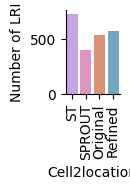

In [40]:
colors = ["#C798EE",'#E88AC2','#ef8a62','#67a9cf']
category_order = ['ST','SPROUT', 'Original', 'Refined']
draw_df = draw_df.sort_values(by='map', key=lambda x: x.map(dict(zip(category_order, range(len(category_order))))))
palette_dict = {cat: color for cat, color in zip(category_order, colors)}
g = sns.FacetGrid(draw_df, col='decon', sharex=False,height=2, aspect=0.7)
g.map_dataframe(sns.barplot, x='map', y='selected',
                hue='map', dodge=False, palette=palette_dict)
#g.add_legend(
g.set_axis_labels('Map', 'Number of LRI') 
for label, ax in g.axes_dict.items():
    ax.set_title('')  # remove the title generated by sns.FacetGrid
    ax.set_xlabel(label)  # use the label from the dataframe as xlabel
    ax.tick_params(axis='x', labelrotation=90) # optionally rotate the tick labels
plt.tight_layout()
plt.show()

In [ ]:
# acquire global_I from spatialdm results
# import scanpy as sc
# after_adata = sc.read(f'{dm_dir}/spex/spatialdm.h5ad')
# before_adata = sc.read(f'{dm_dir}/before/spatialdm.h5ad')
# st_adata = sc.read(f'{dm_dir}/st/spatialdm.h5ad')
# sp_adata = sc.read(f'{dm_dir}/sprout/spatialdm.h5ad')
# pd.DataFrame(pd.Series(sp_adata.uns['global_I'], index=sp_adata.uns['global_res'].index), columns=['SPROUT']).to_csv(f'/data6/wangjingwan/5.Simpute/4.datasets/spaDM/SCC_c2l/orig/global_I.csv')

In [41]:
st_df = pp.read_csv_tsv(f'{dm_dir}/ST/global_I.csv')
sp_df = pp.read_csv_tsv(f'{dm_dir}/sprout/global_I.csv')
ref = pp.read_csv_tsv(f'{dm_dir}/refined/global_I.csv')
bef = pp.read_csv_tsv(f'{dm_dir}/original/global_I.csv')
moran_df = pd.concat([st_df, sp_df, bef, ref], axis=1)
moran_df.dropna(inplace=True)

In [42]:
import scipy.stats as st
import matplotlib.pyplot as plt

def regplot(x, y, hue=None, palette_dict = None, hue_values=None, show_corr=True, legend_on=True,
            **kwargs):
    import seaborn
    if hue is None:
        if show_corr:
            _label = "R=%.3f" %(st.pearsonr(x, y)[0])
        else:
            _label = None
        ax = seaborn.regplot(x, y, label=_label, **kwargs)
    else:
        if hue_values is None:
            hue_values = np.unique(hue)
        for hue_val in hue_values:
            _idx = hue == hue_val
            if show_corr:
                _label = str(hue_val) + ": R=%.3f" %(
                    st.pearsonr(x[_idx], y[_idx])[0])
            else:
                _label = None
            
            ax = seaborn.regplot(x[_idx], y[_idx], label=_label, color = palette_dict[hue_val], **kwargs)
            # ax = seaborn.lmplot(x = 'ST', y = 'X', hue = 'hue',data = df, label=_label, palette=palette_dict)
    
    if legend_on:
        plt.legend()

/home/wangjingwan/.local/lib/python3.8/site-packages/seaborn/_decorators.py:36: FutureWarning:

Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.



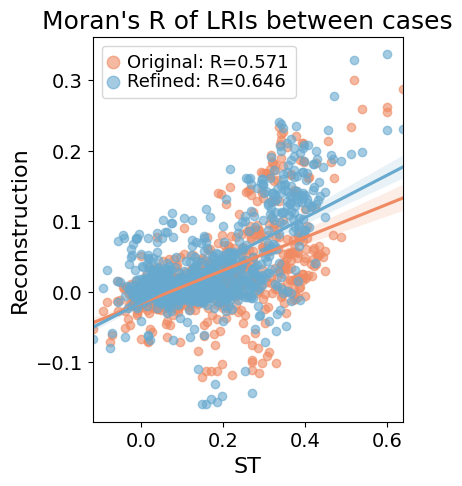

In [43]:
a = moran_df[['ST','Original']]
a.columns = ['ST','X']
b = moran_df[['ST','Refined']]
b.columns = ['ST','X']
df = pd.concat([a,b],axis = 0)
hue = np.array(['Original'] * len(a) + ['Refined'] * len(b))
df['hue'] = hue
plt.figure(figsize=(4,5))
regplot(df['ST'], df['X'], hue, palette_dict = palette_dict,scatter_kws={'alpha':0.6})
plt.legend(fontsize = 13,handletextpad=0.5,columnspacing=0.4,labelspacing=0.1,
            markerscale = 1.5,handlelength = 0.5)
plt.xlabel('ST',fontsize=16)
plt.ylabel('Reconstruction',fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
# plt.axis('equal')
plt.title('Moran\'s R of LRIs between cases',fontsize=18)
plt.show()
# plt.savefig(f'{outDir}/scc_morans.pdf')